In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch

In [3]:
print("pytorch version", torch.__version__)
print("GPU Available", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(device)

pytorch version 2.11.0+cpu
GPU Available False
Device: cpu


## Tensor basics

In [4]:
t1=torch.tensor([1.0, 2.0, 3.0, 4.0])
t2=torch.zeros(3,4)
t3=torch.ones(3,4)
t4=torch.randn(3,4)
print(t1)
print(t2)
print(t3)
print(t4)

tensor([1., 2., 3., 4.])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[-7.5224e-01, -4.9691e-01,  1.7044e+00,  6.3119e-01],
        [ 2.3818e-01, -2.4151e-01,  1.4514e-02, -6.3052e-01],
        [-1.3267e-01, -3.0908e-04,  1.1780e+00, -5.8600e-01]])


In [5]:
print(t3.shape)
print(t3.dtype)

torch.Size([3, 4])
torch.float32


In [6]:
import numpy as np
n=np.array([1,2,3,4])
tensor_from_numpy=torch.from_numpy(n)
back_numpy=tensor_from_numpy.numpy()
print(tensor_from_numpy)
print(back_numpy)

tensor([1, 2, 3, 4])
[1 2 3 4]


In [7]:
a=torch.tensor([1,2,3,4])
b=torch.tensor([3,4,5,6])
print("a*b", a*b)
print(" a dot b", torch.dot(a,b))

a*b tensor([ 3,  8, 15, 24])
 a dot b tensor(50)


## Build the Neural Net class

In [8]:
# Neural Network Architecture
#3-layer feedforward network: 15 input features → 64 → 32 → 1 output (survived/not).

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader , TensorDataset
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv('data/titanic_clean.csv')
x=df.drop(['Survived'],axis=1)
y=df['Survived']
scaler=StandardScaler()
x=scaler.fit_transform(x)
x_train,x_test, y_train, y_test=train_test_split(x,y, test_size=.20, random_state=42, stratify=y)
x_train_t=torch.FloatTensor(x_train)
x_test_t=torch.FloatTensor(x_test)
y_train_t = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_t  = torch.FloatTensor(y_test.values).reshape(-1, 1)
print("x_train tensor shape:", x_train_t.shape)
print("y_train tensor shape:", y_train_t.shape)
print("Data converted to tensors ✓")

x_train tensor shape: torch.Size([712, 15])
y_train tensor shape: torch.Size([712, 1])
Data converted to tensors ✓


In [10]:
# Code cell — define neural net class
class TitanicNet(nn.Module):
    def __init__(self, input_size):
        super(TitanicNet, self).__init__()
        self.network=nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Layer 2
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            # output layer
            nn.Linear(32,1),
            nn.ReLU(),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

        
        

In [11]:
input_size=x_train_t.shape[1]
model=TitanicNet(input_size)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

Total parameters: 3,137


In [12]:
# Code cell — define loss and optimizer

In [13]:
criteria=nn.BCELoss()
optimizer=optim.Adam(model.parameters(), lr=.001)
print("Loss function: BCELoss")
print("Optimizer: Adam (lr=0.001)")
print("Ready to train ✓")

Loss function: BCELoss
Optimizer: Adam (lr=0.001)
Ready to train ✓


In [14]:
# Code cell — training loo

In [19]:
EPOCHS = 100
train_losses = []
train_ac = []

for epoch in range(EPOCHS):
    
    # ✅ FIX 1 — model.train() must be INSIDE loop, before forward pass
    model.train()
    
    output = model(x_train_t)
    loss = criteria(output, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # ✅ FIX 2 — model.eval() inside loop but AFTER optimizer step
    model.eval()
    with torch.no_grad():
        # ✅ FIX 3 — recalculate output in eval mode, don't reuse training output
        eval_output = model(x_train_t)
        predicts = (eval_output > 0.5).float()
        acc = (predicts == y_train_t).float().mean()
        train_ac.append(acc.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/100] | Loss: {loss.item():.4f} | Accuracy: {acc.item():.4f}")
    

Epoch [ 10/100] | Loss: 0.5920 | Accuracy: 0.8315
Epoch [ 20/100] | Loss: 0.5911 | Accuracy: 0.8343
Epoch [ 30/100] | Loss: 0.5829 | Accuracy: 0.8357
Epoch [ 40/100] | Loss: 0.5741 | Accuracy: 0.8357
Epoch [ 50/100] | Loss: 0.5823 | Accuracy: 0.8399
Epoch [ 60/100] | Loss: 0.5791 | Accuracy: 0.8399
Epoch [ 70/100] | Loss: 0.5794 | Accuracy: 0.8399
Epoch [ 80/100] | Loss: 0.5780 | Accuracy: 0.8413
Epoch [ 90/100] | Loss: 0.5809 | Accuracy: 0.8427
Epoch [100/100] | Loss: 0.5783 | Accuracy: 0.8427


In [17]:
# Code cell — plot loss curve + evaluate

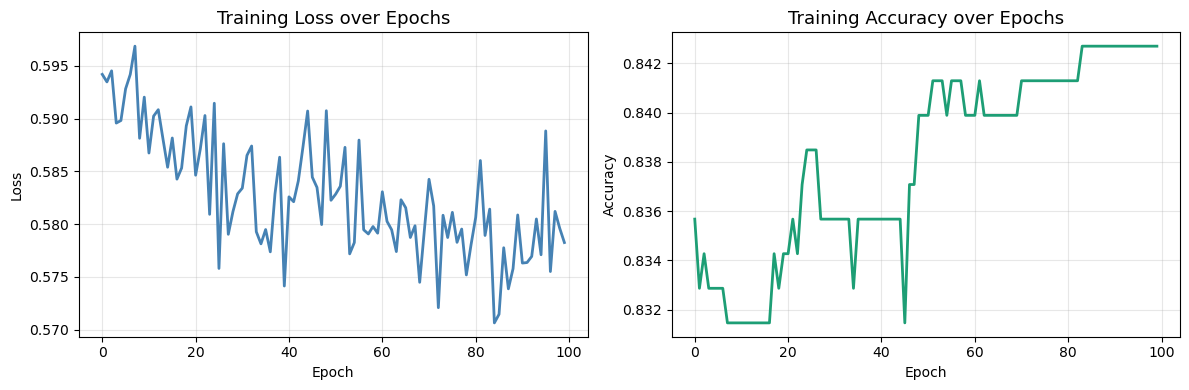

Training curves saved ✓

✅ Test Accuracy: 0.8045 (80.4%)


In [20]:
# Plot training loss curve
os.makedirs('plots', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue', linewidth=2)
ax1.set_title('Training Loss over Epochs', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(train_ac, color='#1D9E75', linewidth=2)
ax2.set_title('Training Accuracy over Epochs', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/day5_training_curves.png', dpi=150)
plt.show()
print("Training curves saved ✓")

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_output = model(x_test_t)
    test_predicted = (test_output > 0.5).float()
    test_acc = accuracy_score(y_test, test_predicted.numpy())

print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

#print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")


In [21]:
os.makedirs('models', exist_ok=True)

# Save model weights
torch.save(model.state_dict(), 'models/titanic_neural_net.pth')
print("Model saved ✓")

# Verify reload works
loaded_model = TitanicNet(input_size)
loaded_model.load_state_dict(torch.load('models/titanic_neural_net.pth'))
loaded_model.eval()
print("Model reload successful ✓")

Model saved ✓
Model reload successful ✓


## Results Comparison — Neural Net vs sklearn Models
Comparing PyTorch neural network with Day 3 sklearn classifiers on same dataset.

In [25]:
# Comparison table — update numbers with your actual results
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Day 3)',
        'Random Forest (Day 3)',
        'SVM (Day 3)',
        'Neural Network PyTorch (Day 5)'
    ],
    'Test Accuracy': [
        0.8492,   # your Day 3 result
        0.8268,   # your Day 3 result
        0.6704,   # your Day 3 result (before scaling)
        test_acc  # today's result — auto filled
    ],
    'Type': [
        'Classical ML',
        'Ensemble',
        'Classical ML',
        'Deep Learning'
    ]
})
comparison['Test Accuracy'] = comparison['Test Accuracy'].round(4)
comparison = comparison.sort_values('Test Accuracy', ascending=False)
print(comparison.to_string(index=False))
print(f"\n🏆 Best overall: {comparison.iloc[0]['Model']}")

                         Model  Test Accuracy          Type
   Logistic Regression (Day 3)         0.8492  Classical ML
         Random Forest (Day 3)         0.8268      Ensemble
Neural Network PyTorch (Day 5)         0.8045 Deep Learning
                   SVM (Day 3)         0.6704  Classical ML

🏆 Best overall: Logistic Regression (Day 3)
